In [1]:
import os
import numpy as np
import proplot as pplt
from matplotlib.ticker import LogLocator, ScalarFormatter

arr = np.load('your_directory/loads/subregion_mask.npz', allow_pickle=True)['id_to_subregion']
label_list = arr[:, 1].tolist()
label_list = [s.replace('NorthernGrid', 'NG').replace('WestConnect', 'WC') for s in label_list]
label_list = [s.replace('Central', 'C').replace('North', 'N').replace('South', 'S').replace('East', 'E').replace('West', 'W') for s in label_list]

/tmp/ipykernel_829205/2795742605.py:32: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  fig.tight_layout()
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: 

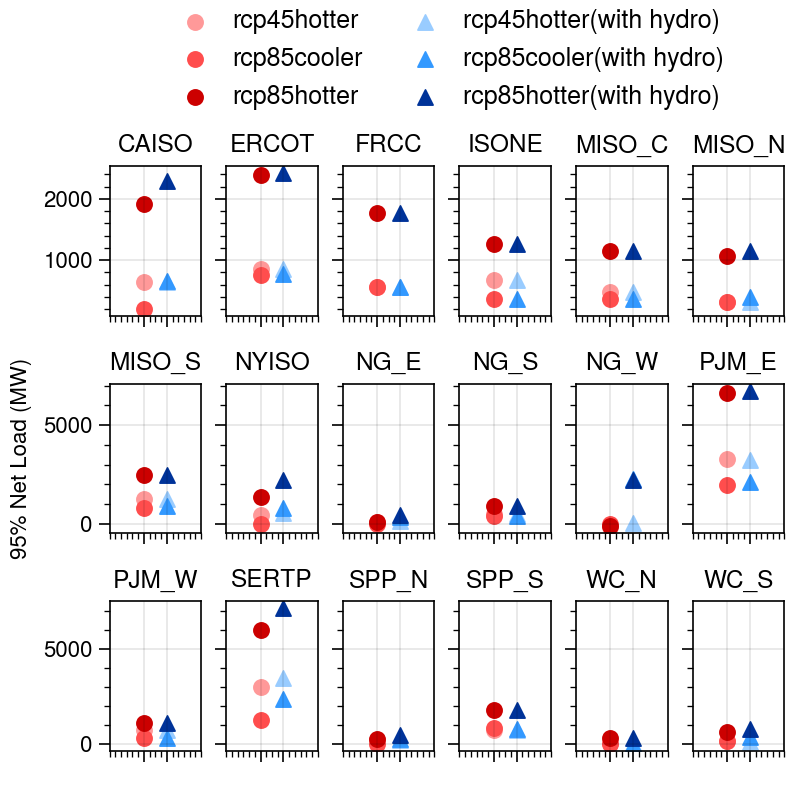

In [2]:
climate_scenarios = ['rcp45hotter', 'rcp85cooler', 'rcp85hotter']
data50 = np.load('/datasets/future_analysis/dist/loadgen_2050.npz', allow_pickle=True)['p95']
data50 = data50 - data50[:, [0]]
hydro50 = np.load('/datasets/future_analysis/dist/loadgenhydro_2050.npz', allow_pickle=True)['p95']
hydro50 = hydro50 - hydro50[:, [0]]
fig, axs = pplt.subplots(nrows=3, ncols=6, figsize=(4, 4), sharey=True, wspace=1)
fig.patch.set_facecolor('white')
red_shades = ['#ff9999', '#ff4d4d', '#cc0000']     
blue_shades = ['#99ccff', '#3399ff', '#003399']    

for i in range(18):
    ax = axs[i]
    for j in range(3):  
        if i == 0:
            ax.scatter(1, data50[i, j+1], color=red_shades[j], marker='o', s=30, label=f'{climate_scenarios[j]}')
            ax.scatter(1.4, hydro50[i, j+1], color=blue_shades[j], marker='^', s=30, label=f'{climate_scenarios[j]}(with hydro)')
        else:
            ax.scatter(1, data50[i, j+1], color=red_shades[j], marker='o', s=30)
            ax.scatter(1.4, hydro50[i, j+1], color=blue_shades[j], marker='^', s=30)
        ax.format(xlim=(0.4, 2), xticks=[1, 1.4],xticklabels=[' ',' '],
            title=f'{label_list[i]}',fontsize=8)
    if i == 6:
        ax.format(ylabel='95% Net Load (MW)', fontsize=8)
fig.legend(loc = 'top',ncols=2,frame=False)
fig.tight_layout()
fig.show()